<a href="https://colab.research.google.com/github/Kdshah1512/Academics-projects/blob/main/Mop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Title:loan default prediction

Import neccesary libraries

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier










Loading dataset

In [ ]:
file_path = 'train.csv'
data = pd.read_csv(file_path)
print("Preview of the dataset:")
print(data.head())
print("\nDataset Info:")
data.info()


Preview of the dataset:
   Id Home Ownership  Annual Income Years in current job  Tax Liens  \
0   0       Own Home       482087.0                  NaN        0.0   
1   1       Own Home      1025487.0            10+ years        0.0   
2   2  Home Mortgage       751412.0              8 years        0.0   
3   3       Own Home       805068.0              6 years        0.0   
4   4           Rent       776264.0              8 years        0.0   

   Number of Open Accounts  Years of Credit History  Maximum Open Credit  \
0                     11.0                     26.3             685960.0   
1                     15.0                     15.3            1181730.0   
2                     11.0                     35.0            1182434.0   
3                      8.0                     22.5             147400.0   
4                     13.0                     13.6             385836.0   

   Number of Credit Problems  Months since last delinquent  Bankruptcies  \
0               

Data Exploration

In [ ]:
print("\n--- Dataset Overview ---")
print(data.info())


print("\n--- Statistical Summary ---")
print(data.describe())

missing_values = data.isnull().sum()
print("\n--- Missing Values ---")
print(missing_values)



--- Dataset Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Id                            7500 non-null   int64  
 1   Home Ownership                7500 non-null   object 
 2   Annual Income                 5943 non-null   float64
 3   Years in current job          7129 non-null   object 
 4   Tax Liens                     7500 non-null   float64
 5   Number of Open Accounts       7500 non-null   float64
 6   Years of Credit History       7500 non-null   float64
 7   Maximum Open Credit           7500 non-null   float64
 8   Number of Credit Problems     7500 non-null   float64
 9   Months since last delinquent  3419 non-null   float64
 10  Bankruptcies                  7486 non-null   float64
 11  Purpose                       7500 non-null   object 
 12  Term                          7500 n

Target variable distribution and visulization


--- Target Variable Distribution ---
Credit Default
0    0.718267
1    0.281733
Name: proportion, dtype: float64


<ipython-input-4-f6a757aa8e9f>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_distribution.index, y=target_distribution.values, palette='viridis')


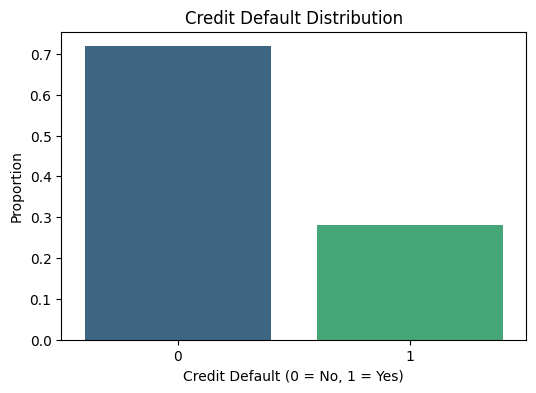

In [ ]:
target_distribution = data['Credit Default'].value_counts(normalize=True)
print("\n--- Target Variable Distribution ---")
print(target_distribution)


plt.figure(figsize=(6, 4))
sns.barplot(x=target_distribution.index, y=target_distribution.values, palette='viridis')
plt.title('Credit Default Distribution')
plt.xlabel('Credit Default (0 = No, 1 = Yes)')
plt.ylabel('Proportion')
plt.show()


Data preprocessing

In [ ]:

data = data.dropna(subset=['Credit Default'])


data['Annual Income'] = data['Annual Income'].fillna(data['Annual Income'].median())
data['Credit Score'] = data['Credit Score'].fillna(data['Credit Score'].median())


data['Years in current job'] = data['Years in current job'].fillna(data['Years in current job'].mode()[0])

numerical_columns = ['Annual Income', 'Credit Score', 'Tax Liens']
scaler = StandardScaler()
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])


split data

In [ ]:
# Split data into features and target variable
X = data.drop('Credit Default', axis=1)
y = data['Credit Default']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




missing data heatmap

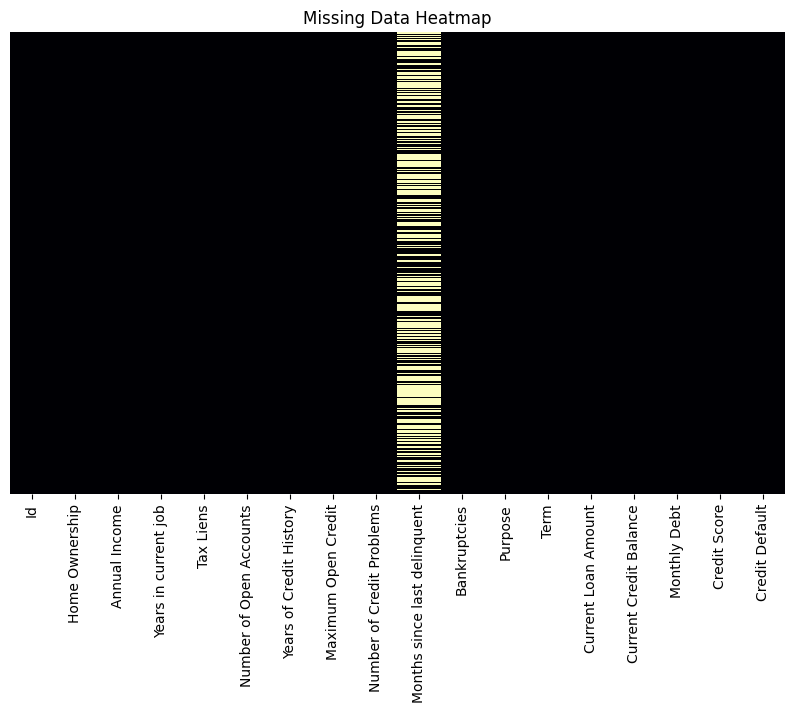

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='magma', yticklabels=False)
plt.title('Missing Data Heatmap')
plt.show()


Basic Model Accuracies Plot

In [ ]:



import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Assuming you have already trained the models and made predictions:
# Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model = LogisticRegression(random_state=42)



from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test_tfidf)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

# Random Forest
y_pred_rf = best_rf_model.predict(X_test_tfidf)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Collect accuracies dynamically
basic_model_accuracies = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_dt, accuracy_rf]
}

# Convert to DataFrame
basic_model_df = pd.DataFrame(basic_model_accuracies)

# Visualization
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=basic_model_df, palette='viridis')
plt.title('Basic Model Accuracies')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0.7, 1.0)  # Adjust range as needed
plt.show()


ValueError: could not convert string to float: 'Rent'

Experimental segment

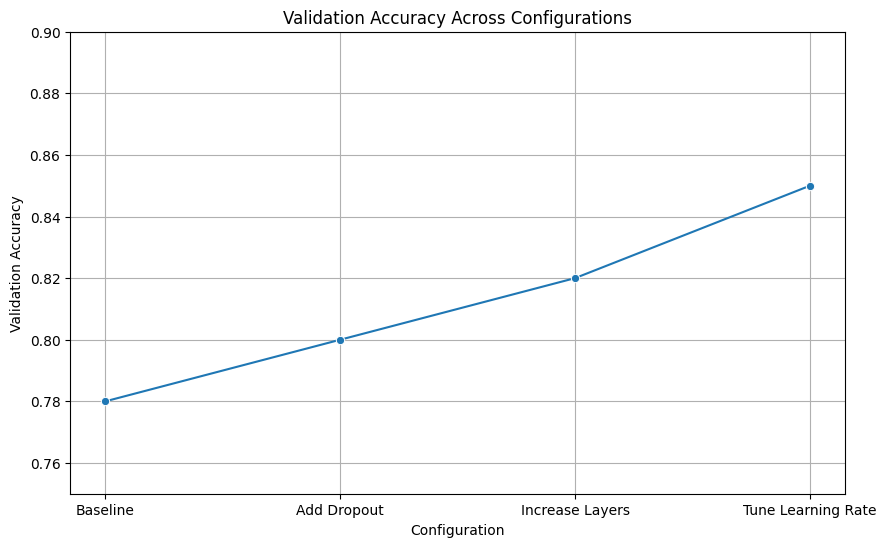

In [ ]:
experiment_results={
    'Configuration': ['Baseline', 'Add Dropout', 'Increase Layers', 'Tune Learning Rate'],
    'Validation Accuracy': [0.78, 0.80, 0.82, 0.85]
}
experiment_df = pd.DataFrame(experiment_results)

plt.figure(figsize=(10, 6))
sns.lineplot(x='Configuration', y='Validation Accuracy', data=experiment_df, marker='o')
plt.title('Validation Accuracy Across Configurations')
plt.ylabel('Validation Accuracy')
plt.xlabel('Configuration')
plt.ylim(0.75, 0.9)
plt.grid(True)
plt.show()

Best model for hyperparameter

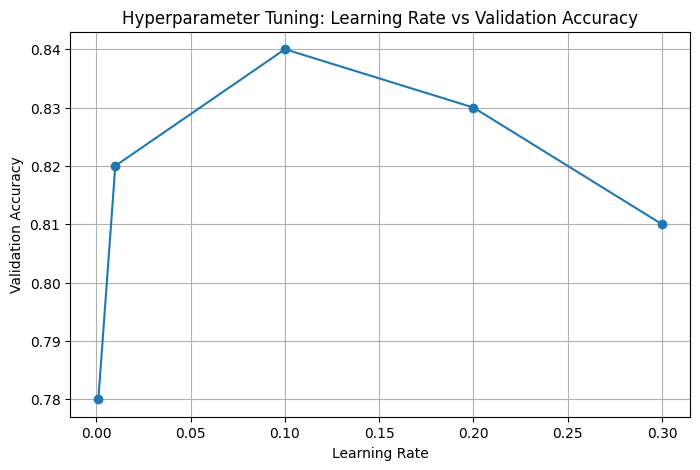

In [ ]:
learning_rates = [0.001, 0.01, 0.1, 0.2, 0.3]
validation_accuracies = [0.78, 0.82, 0.84, 0.83, 0.81]

plt.figure(figsize=(8, 5))
plt.plot(learning_rates, validation_accuracies, marker='o')
plt.title('Hyperparameter Tuning: Learning Rate vs Validation Accuracy')
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

Model Evaluation: Precision, Recall, and F1-Score